In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
from aspect_turquoise import Turquoise

In [4]:
from generator_core import SimpleVocabulary
from generator_core import Trainer, SolutionManager

In [5]:
from typing import Generator
import numpy as np
import torch
import matplotlib.pyplot as plt

In [6]:
manager = SolutionManager(Turquoise)

In [7]:
manager.prepare_solution()

In [8]:
manager.set_batch_size(512)

In [9]:
manager.trainer = Trainer(
    model=manager.model,
    train_dataloader=manager._training_data_loader(),
    epochs=1,
    dataset_fraction=10,
    optimizer=lambda params: torch.optim.Adam(params, lr=0.003),
    model_train_step=lambda model, data: model(data[0], data[1]),
    device="cuda",
)

In [10]:
manager.trainer.train()

Epoch:  1/ 1    Train Loss: 10.88    TTS: 3.23    ETA: 0.00
Epoch:  1/ 1    Train Loss: 10.83    TTS: 6.76    ETA: 0.00
Epoch:  1/ 1    Train Loss: 10.60    TTS: 13.79    ETA: 0.00
Epoch:  1/ 1    Train Loss: 10.01    TTS: 16.93    ETA: 0.00
Epoch:  1/ 1    Train Loss: 8.70    TTS: 31.13    ETA: 0.00
Epoch:  1/ 1    Train Loss: 7.12    TTS: 34.67    ETA: 0.00
Epoch:  1/ 1    Train Loss: 7.15    TTS: 46.53    ETA: 0.00
Epoch:  1/ 1    Train Loss: 6.78    TTS: 48.37    ETA: 0.00
Epoch:  1/ 1    Train Loss: 6.62    TTS: 59.74    ETA: 0.00
Epoch:  1/ 1    Train Loss: 6.71    TTS: 62.48    ETA: 0.00
Epoch: 2/1, Train Loss=8.44795, Val Loss=-1.00000


In [ ]:
manager.trainer.loss["train"]

In [69]:
def do_the_shit(sample):
    preds = manager.model(torch.asarray(sample[None, :], dtype=torch.long, device=manager.trainer.device), torch.asarray([len(sample)], dtype=torch.long, device=manager.trainer.device))
    preds_home = preds.cpu().numpy()
    return preds_home

with torch.no_grad():
    sample = next(iter(manager._stream_samples()))
    for i in range(1, 100, 10):
        print(" ".join([manager.solution.vocabulary.decode(int(hmm)) for hmm in sample[max(0, i-5):i+1]]))
        preds_home = do_the_shit(sample[:i])
        print("   ", manager.solution.vocabulary.decode(preds_home[0].argmax()))

<SONG_START> look
    well
it's a wonderful face <LINE> and
    <LINE>
to me <LINE> look at the
    the
when she sees me <LINE> how
    <LINE>
be ? <LINE> <LINE> she's just
    just
, she makes me feel fine
    fine
believe that she could be mine
    mine
my kind of girl , without
    you
and if she ever leaves me
    me
, what could i do ?
    ,


In [74]:
psam = [manager.solution.vocabulary.encode(x) for x in "<SONG_START> look , it's a wonderful face".split(" ")]
with torch.no_grad():
    for i in range(50):
        preds_home = do_the_shit(np.asarray(psam[max(0, i - 10):]))[0].argmax()
        word = manager.solution.vocabulary.decode(preds_home)
        print(word, end=' ')
        psam.append(preds_home)

, it's a boom - boomerang is love <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> <LINE> 

In [54]:
" ".join([manager.solution.vocabulary.decode(int(x)) for x in sample])

"<SONG_START> look at her face , it's a wonderful face <LINE> and it means something special to me <LINE> look at the way that she smiles when she sees me <LINE> how lucky can one fellow be ? <LINE> <LINE> she's just my kind of girl , she makes me feel fine <LINE> who could ever believe that she could be mine ? <LINE> she's just my kind of girl , without her i'm blue <LINE> and if she ever leaves me what could i do , what could i do ? <LINE> <LINE> and when we go for a walk in the park <LINE> and she holds me and squeezes my hand <LINE> we'll go on walking for hours and talking <LINE> about all the things that we plan <LINE> <LINE> she's just my kind of girl , she makes me feel fine <LINE> who could ever believe that she could be mine ? <LINE> she's just my kind of girl , without her i'm blue <LINE> and if she ever leaves me what could i do , what could i do ? <SONG_END>"

In [47]:
manager.solution.vocabulary.decode(preds_home[0].argmax())

'tune'

In [38]:
preds_home.shape

(1, 53433)

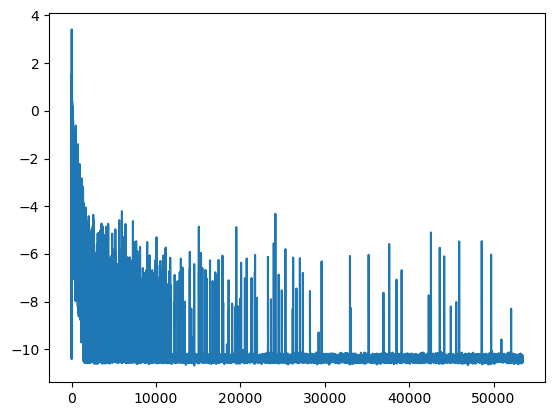

In [39]:
plt.plot(preds_home[0])
plt.show()